# Learned vs Fixed Metric — Small Examples w/ Auto Hyperparameter Search

This notebook reproduces the **small examples** workflow and augments it with **automatic hyperparameter search** for both the **fixed** and **learned** induced-metric optimizers. It also compares against the standard baselines used in the original analysis (SGD, Adam, AdamW, Muon when available).

Key points:

- Benchmarks: **Rosenbrock, Rastrigin, Himmelblau, Beale, Ackley** (2D).
- Stopping: stop when within `tol = 1e-10` of the known global minimum, or hit `max_steps`.
- Selection: among runs that reach tolerance, pick **lowest wall-time**; otherwise pick the run **closest to the minimum**.
- Fixed vs Learned:
  - Fixed: `optimisers/jax_fixed.py` (plain + optional log-loss & RMS variants).
  - Learned: `optimisers/jax_learnable.py` (plain + optional log-loss).

> This is designed to match the spirit of your original `small_examples.ipynb` and figures, while letting you search for the **optimal hyperparameters** of both families in one place.

In [1]:
# Imports & environment setup
import time, math, itertools, json
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt

import sys, os
# Add parent directory to path for importing optimisers
notebook_dir = os.getcwd()
parent_dir = os.path.dirname(notebook_dir)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

import jax
import jax.numpy as jnp
import optax

from tqdm import tqdm

from optimisers import jax_fixed, jax_learnable

## Benchmark functions (2D)

We use the same five classical functions as the original small examples:
**Rosenbrock, Rastrigin, Himmelblau, Beale, Ackley**.

In [2]:
# JAX definitions of the benchmarks
def rosenbrock(theta, a=1.0, b=100.0):
    x, y = theta[0], theta[1]
    return (a - x)**2 + b*(y - x**2)**2

def rastrigin(theta, A=10.0):
    x, y = theta[0], theta[1]
    return 2*A + (x**2 - A*jnp.cos(2*jnp.pi*x)) + (y**2 - A*jnp.cos(2*jnp.pi*y))

def himmelblau(theta):
    x, y = theta[0], theta[1]
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

def beale(theta):
    x, y = theta[0], theta[1]
    term1 = (1.5 - x + x*y)
    term2 = (2.25 - x + x*y**2)
    term3 = (2.625 - x + x*y**3)
    return term1**2 + term2**2 + term3**2

def ackley(theta, a=20.0, b=0.2, c=2*jnp.pi):
    x, y = theta[0], theta[1]
    term1 = -a * jnp.exp(-b * jnp.sqrt((x**2 + y**2)/2.0))
    term2 = -jnp.exp((jnp.cos(c*x) + jnp.cos(c*y))/2.0)
    return term1 + term2 + a + jnp.e

BENCHES = {
    "rosenbrock": {"fn": rosenbrock,  "theta_star": jnp.array([1.0, 1.0]), "f_star": 0.0, "start": np.array([-1.2, 1.0], dtype=np.float32)},
    "rastrigin":  {"fn": rastrigin,   "theta_star": jnp.array([0.0, 0.0]), "f_star": 0.0, "start": np.array([3.0, 4.0], dtype=np.float32)},
    "himmelblau": {"fn": himmelblau,  "theta_star": jnp.array([3.0, 2.0]), "f_star": 0.0, "start": np.array([-2.0, 2.0], dtype=np.float32)},
    "beale":      {"fn": beale,       "theta_star": jnp.array([3.0, 0.5]), "f_star": 0.0, "start": np.array([-1.0, 1.0], dtype=np.float32)},
    "ackley":     {"fn": ackley,      "theta_star": jnp.array([0.0, 0.0]), "f_star": 0.0, "start": np.array([2.0, 2.0], dtype=np.float32)},
}

## Hyperparameter grids

We provide **default grids** that you can edit. For the small examples, the paper set `β=1` (no batching) and used **no weight decay**. We keep that here by default.

> You can shrink/enlarge these grids to trade off runtime vs thoroughness.

In [ ]:
LEARNING_RATES   = [1e-6, 1e-5, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0]
MOMENTUM_VALUES  = [0.0, 0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]
BETA_RMS_VALUES  = [0.8, 0.85, 0.9, 0.99, 0.999]
BETA1_VALUES     = MOMENTUM_VALUES
BETA2_VALUES     = BETA_RMS_VALUES
EPS_VALUES       = [1e-8]
XI_VALUES        = [0.01, 0.1, 1.0, 10.0]
MUON_BETA_VALUES = [0.9, 0.99, 0.99]

SEARCH = {
    # Fixed induced-metric (Alg. 1 plain)
    "fixed_plain": {
        "learning_rate": LEARNING_RATES,
        "momentum":      MOMENTUM_VALUES,
        "xi":            XI_VALUES,
        "beta":          [0.8],
        "weight_decay":  [0.0],
    },
    # Learned diag inverse-metric
    "learn_plain": {
        "learning_rate": LEARNING_RATES,
        "momentum":      MOMENTUM_VALUES,
        "xi":            XI_VALUES,
        "beta":          [0.8],
        "weight_decay":  [0.0],
        "metric_lr":     [1e-3, 5e-4, 1e-4],
        "metric_reg":    [0.0, 1e-4],
        "metric_clip":   [4.0],
    },
    # Baselines
    "sgd": {
        "learning_rate": LEARNING_RATES,
        "momentum":      MOMENTUM_VALUES,
        "weight_decay":  [0.0],
        "nesterov":      [False],
    },
    "adam": {
        "learning_rate": LEARNING_RATES,
        "b1": BETA1_VALUES,
        "b2": BETA2_VALUES,
        "eps": EPS_VALUES,
        "weight_decay": [0.0],
    },
    "adamw": {
        "learning_rate": LEARNING_RATES,
        "b1": BETA1_VALUES,
        "b2": BETA2_VALUES,
        "eps": EPS_VALUES,
        "weight_decay": [0.0, 1e-4],
    },
    # Muon
    "muon": {
        "learning_rate": LEARNING_RATES,
        "adam_b1": BETA1_VALUES,
        "adam_b2": BETA2_VALUES,
        "eps": EPS_VALUES,
        "beta": MUON_BETA_VALUES,
    },
}

SEARCH_SIZE = {}
for name, params in SEARCH.items():
    sizes = [len(v) for v in params.values()]
    total = 1
    for s in sizes:
        total *= s
    SEARCH_SIZE[name] = total
SEARCH_SIZE_TOTAL = sum(SEARCH_SIZE.values())

MAX_STEPS = 2000
TOL       = 1e-10
RNG_SEED  = 0

print("Search sizes per optimiser:")
for name, size in SEARCH_SIZE.items():
    print(f"  {name}: {size}")
print(f"Total search size: {SEARCH_SIZE_TOTAL}")

Search sizes per optimiser:
  fixed_plain: 288
  learn_plain: 1728
  sgd: 72
  adam: 360
  adamw: 720
  muon: 1080
Total search size: 4248


In [4]:
from typing import Dict, Any, Tuple

def rank_key(res: Dict[str, Any]):
    # Prefer converged; then faster runtime; then smaller final loss.
    return (
        0 if res["converged"] else 1,
        res["runtime_ms"],
        res["final_loss"],
    )

def grid_iter(space: Dict[str, list]):
    keys = list(space.keys())
    for values in itertools.product(*[space[k] for k in keys]):
        yield dict(zip(keys, values))

def as_float(x):
    try:
        return float(x)
    except Exception:
        return x

In [5]:
import jax
import jax.numpy as jnp
import optax

def make_vg(f):
    return jax.jit(jax.value_and_grad(f))

def run_optax_stepper(theta0, f, make_opt, update_fn, needs_loss=False, max_steps=MAX_STEPS, tol=TOL):
    vg = make_vg(lambda th: f(th))
    th = jnp.array(theta0)
    opt = make_opt(th)
    st  = opt.init(th)
    losses = []
    t0 = time.time()
    converged = False
    for step in range(1, max_steps+1):
        loss, grad = vg(th)
        if needs_loss:
            updates, st = update_fn(opt, grad, st, loss, th)
        else:
            updates, st = update_fn(opt, grad, st, None, th)
        th = optax.apply_updates(th, updates)
        losses.append(float(loss))
        if abs(float(loss)) <= tol:
            converged = True
            break
    ms = 1000.0*(time.time() - t0)
    return {
        "losses": losses,
        "runtime_ms": ms,
        "steps": step,
        "final_loss": losses[-1],
        "converged": converged,
    }

# Builders & update wrappers for each optimizer
def build_fixed_plain(hp):
    def make_opt(_params):
        return jax_fixed.custom_sgd(**hp)
    def update_fn(opt, grad, st, loss, params):
        return opt.update(grad, st, params)
    return make_opt, update_fn, False

def build_learn_plain(hp):
    def make_opt(_params):
        return jax_learnable.custom_sgd_learnable_diag(**hp)
    def update_fn(opt, grad, st, loss, params):
        return opt.update(grad, st, params)
    return make_opt, update_fn, False

def build_sgd(hp):
    def make_opt(_params):
        return optax.sgd(learning_rate=hp["learning_rate"],
                            momentum=hp["momentum"],
                            nesterov=hp.get("nesterov", False))
    def update_fn(opt, grad, st, loss, params):
        return opt.update(grad, st)
    return make_opt, update_fn, False

def build_adam(hp):
    def make_opt(_params):
        return optax.adam(learning_rate=hp["learning_rate"], b1=hp["b1"], b2=hp["b2"], eps=hp["eps"])
    def update_fn(opt, grad, st, loss, params):
        return opt.update(grad, st)
    return make_opt, update_fn, False

def build_adamw(hp):
    def make_opt(_params):
        return optax.adamw(learning_rate=hp["learning_rate"], b1=hp["b1"], b2=hp["b2"], eps=hp["eps"], weight_decay=hp["weight_decay"])
    def update_fn(opt, grad, st, loss, params):
        return opt.update(grad, st, params)
    return make_opt, update_fn, False

def build_muon(hp):
    def make_opt(_params):
        return optax.contrib.muon(**hp)
    def update_fn(opt, grad, st, loss, params):
        return opt.update(grad, st, params)
    return make_opt, update_fn, False

In [6]:
def search_one_function(name, max_steps=MAX_STEPS, tol=TOL):
    counter = tqdm(total=SEARCH_SIZE_TOTAL, desc=f"Searching {name}")

    bench = BENCHES[name]
    f = bench["fn"]
    start = bench["start"]

    results = {}

    # Fixed plain
    best = None; best_hp=None
    for hp in grid_iter(SEARCH["fixed_plain"]):
        counter.update(1)
        make_opt, update_fn, needs_loss = build_fixed_plain(hp)
        out = run_optax_stepper(start, f, make_opt, update_fn, needs_loss, max_steps, tol)
        rec = {"opt": "fixed_plain", "hp": hp, **out}
        if best is None or rank_key(rec) < rank_key(best):
            best, best_hp = rec, hp
    results["fixed_plain"] = best

    # Learned plain
    best = None; best_hp=None
    for hp in grid_iter(SEARCH["learn_plain"]):
        counter.update(1)
        make_opt, update_fn, needs_loss = build_learn_plain(hp)
        out = run_optax_stepper(start, f, make_opt, update_fn, needs_loss, max_steps, tol)
        rec = {"opt": "learn_plain", "hp": hp, **out}
        if best is None or rank_key(rec) < rank_key(best):
            best, best_hp = rec, hp
    results["learn_plain"] = best

    # Baselines
    # SGD
    best = None; best_hp=None
    for hp in grid_iter(SEARCH["sgd"]):
        counter.update(1)
        make_opt, update_fn, needs_loss = build_sgd(hp)
        out = run_optax_stepper(start, f, make_opt, update_fn, needs_loss, max_steps, tol)
        rec = {"opt": "sgd", "hp": hp, **out}
        if best is None or rank_key(rec) < rank_key(best):
            best, best_hp = rec, hp
    results["sgd"] = best

    # Adam
    best = None; best_hp=None
    for hp in grid_iter(SEARCH["adam"]):
        counter.update(1)
        make_opt, update_fn, needs_loss = build_adam(hp)
        out = run_optax_stepper(start, f, make_opt, update_fn, needs_loss, max_steps, tol)
        rec = {"opt": "adam", "hp": hp, **out}
        if best is None or rank_key(rec) < rank_key(best):
            best, best_hp = rec, hp
    results["adam"] = best

    # AdamW
    best = None; best_hp=None
    for hp in grid_iter(SEARCH["adamw"]):
        counter.update(1)
        make_opt, update_fn, needs_loss = build_adamw(hp)
        out = run_optax_stepper(start, f, make_opt, update_fn, needs_loss, max_steps, tol)
        rec = {"opt": "adamw", "hp": hp, **out}
        if best is None or rank_key(rec) < rank_key(best):
            best, best_hp = rec, hp
    results["adamw"] = best

    # Muon
    best = None; best_hp=None
    for hp in grid_iter(SEARCH["muon"]):
        counter.update(1)
        make_opt, update_fn, needs_loss = build_muon(hp)
        out = run_optax_stepper(start, f, make_opt, update_fn, needs_loss, max_steps, tol)
        rec = {"opt": "muon", "hp": hp, **out}
        if best is None or rank_key(rec) < rank_key(best):
            best, best_hp = rec, hp
    results["muon"] = best

    counter.close()

    return results

In [7]:
ALL_RESULTS = {}

for name in BENCHES.keys():
    ALL_RESULTS[name] = search_one_function(name, max_steps=MAX_STEPS, tol=TOL)

Searching ackley: 100%|██████████| 4248/4248 [46:10<00:00,  1.53it/s]


In [8]:
def plot_function_results(name, res):
    # Plot loss vs iteration for the best run of each optimizer (log y)
    plt.figure()
    plt.yscale("log")
    for k, r in res.items():
        if r is None: 
            continue
        plt.plot(r["losses"], label=k)
    plt.title(f"{name}: loss vs iteration (best per optimizer)")
    plt.xlabel("iteration"); plt.ylabel("loss")
    plt.legend()
    plt.show()

def summarize_table(res_all):
    import pandas as pd
    rows = []
    for fn_name, res in res_all.items():
        for k, r in res.items():
            if r is None: continue
            rows.append(dict(
                function = fn_name,
                optimizer = k,
                converged = r["converged"],
                steps = r["steps"],
                runtime_ms = round(r["runtime_ms"], 3),
                final_loss = r["final_loss"],
                hp = json.dumps({kk: float(vv) if isinstance(vv,(int,float)) else vv for kk,vv in r["hp"].items()})
            ))
    df = pd.DataFrame(rows)
    try:
        from caas_jupyter_tools import display_dataframe_to_user
        display_dataframe_to_user("learned_vs_fixed_grid_search_summary", df)
    except Exception:
        print(df)
    return df

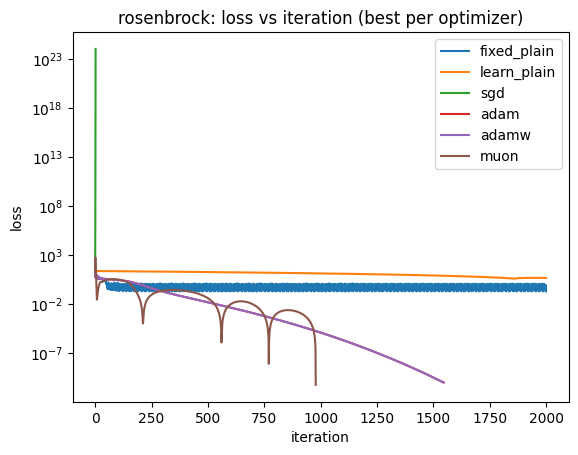

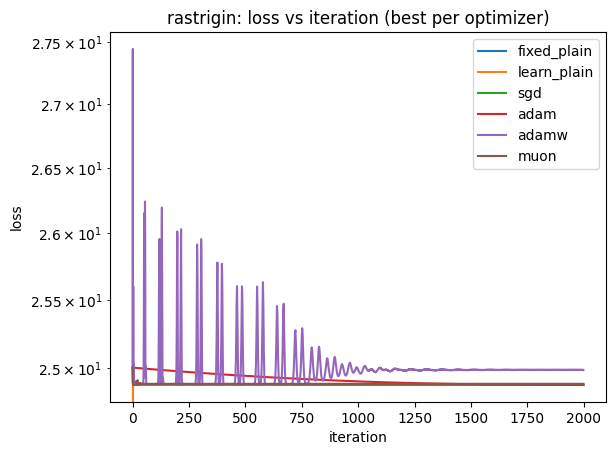

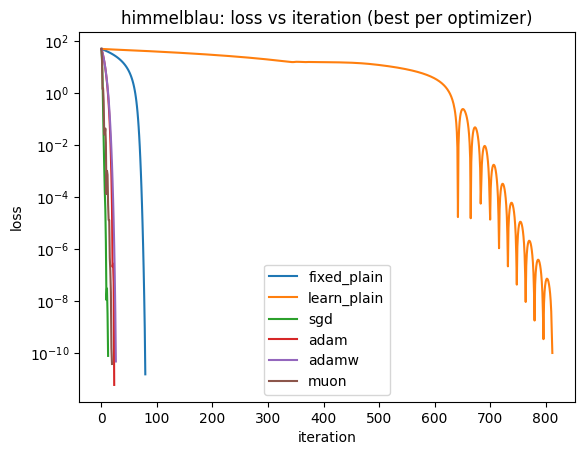

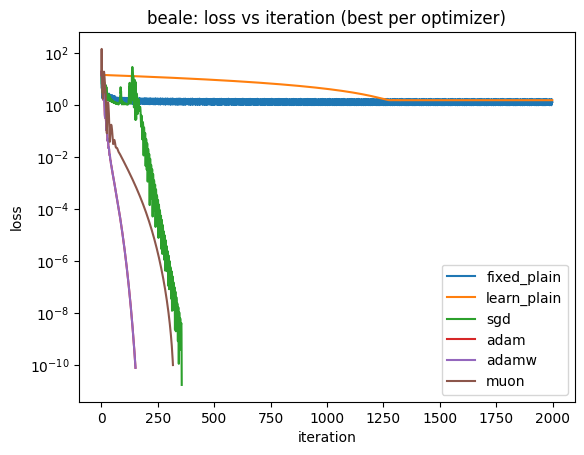

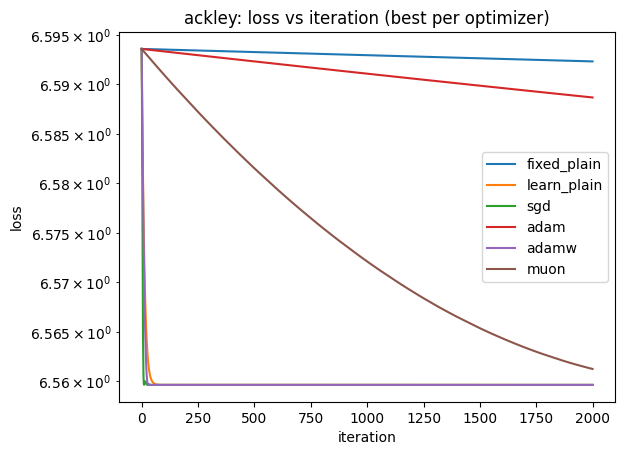

      function    optimizer  converged  steps  runtime_ms    final_loss  \
0   rosenbrock  fixed_plain      False   2000     163.738  2.023083e-01   
1   rosenbrock  learn_plain      False   2000     169.776  4.778170e+00   
2   rosenbrock          sgd      False   2000     171.625           NaN   
3   rosenbrock         adam       True   1546     840.789  9.992353e-11   
4   rosenbrock        adamw       True   1546     522.427  9.992353e-11   
5   rosenbrock         muon       True    979     714.916  5.628993e-11   
6    rastrigin  fixed_plain       True      2      54.681  0.000000e+00   
7    rastrigin  learn_plain       True      2      59.715  0.000000e+00   
8    rastrigin          sgd      False   2000     173.844  2.487384e+01   
9    rastrigin         adam      False   2000     620.426  2.487386e+01   
10   rastrigin        adamw      False   2000     660.169  2.498232e+01   
11   rastrigin         muon      False   2000    1312.211  2.488184e+01   
12  himmelblau  fixed_pla

In [9]:
if len(ALL_RESULTS):
    for name, res in ALL_RESULTS.items():
        plot_function_results(name, res)
    _ = summarize_table(ALL_RESULTS)
else:
    print("No results to visualize.")

## Tips

- To reproduce the *exact* behavior of your original `small_examples`, you can set `MAX_STEPS`, `TOL`, and the starting points to match your prior setup. This notebook already uses the same stopping criterion and similar starts.
- The default grids are intentionally small. If you have time, **widen them**, especially for `xi` and the **learned metric**’s `metric_lr`.
- If Muon is not installed in your environment, that comparison will be skipped automatically.